In [1]:
import sys
!{sys.executable} -m pip install -e .

Defaulting to user installation because normal site-packages is not writeable
Obtaining file:///sdf/group/neutrino/pgranger/larnd-sim-jax
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for larndsim (pyproject.toml) ... done
  Created wheel for larndsim: filename=larndsim-0.1.dev283+ga1569e19c.d20251030-py3-none-any.whl size=10154 sha256=e21b135bf677633b9c3011e4a2297797d01bb8694db66ea115a56e4364ce34cd
  Stored in directory: /lscratch/pgranger/tmp/pip-ephem-wheel-cache-ddoxnstu/wheels/e7/e6/52/708c2eabf9d963fabdda3635808ffba6fe643aaaafd1316c9c
Successfully built larndsim
  Attempting uninstall: larndsim
    Found existing installation: larndsim 0.1.dev283+ga1569e19c.d20251029
    Uninstalling larndsim-0.1.dev283+ga1569e19c.d20251029:
      Successfully uninstalled lar

In [17]:
import h5py
with h5py.File("adc_output.h5", 'r') as f:
    results = f['results'][:]
    results_ticks = f['results_ticks'][:]

with h5py.File("../larnd-sim-jax-bak/adc_output.h5", 'r') as f:
    results_old = f['results'][:]
    results_ticks_old = f['results_ticks'][:]

(array([   0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0., 2064.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.]),
 array([-0.5       , -0.49000001, -0.47999999, -0.47      , -0.46000001,
        -0.44999999, -0.44      , -0.43000001, -0.41999999, -0.41      ,
        -0.40000001, -0.38999999, -0.38      , -0.37    

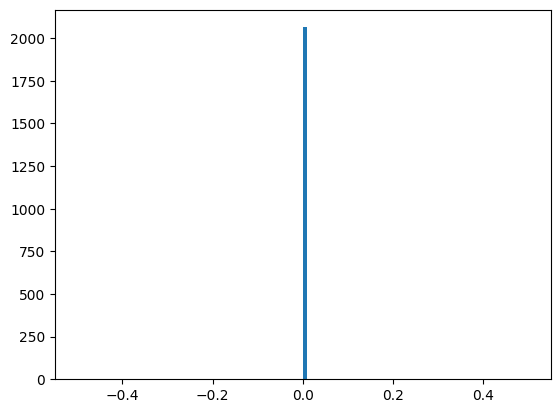

In [18]:
import matplotlib.pyplot as plt

plt.hist(results[:,0].flatten() - results_old[:,0].flatten(), bins=100)

In [8]:
results

array([[[ 9299.903 , 10036.838 ,     0.    , ...,     0.    ,
             0.    ,     0.    ],
        [    0.    ,     0.    ,     0.    , ...,     0.    ,
             0.    ,     0.    ],
        [    0.    ,     0.    ,     0.    , ...,     0.    ,
             0.    ,     0.    ],
        ...,
        [12821.453 , 31368.553 ,     0.    , ...,     0.    ,
             0.    ,     0.    ],
        [ 7529.9023, 15133.885 ,     0.    , ...,     0.    ,
             0.    ,     0.    ],
        [ 8603.229 ,     0.    ,     0.    , ...,     0.    ,
             0.    ,     0.    ]],

       [[ 9424.744 ,     0.    ,  9831.852 , ...,     0.    ,
             0.    ,     0.    ],
        [    0.    ,     0.    ,     0.    , ...,     0.    ,
             0.    ,     0.    ],
        [    0.    ,     0.    ,     0.    , ...,     0.    ,
             0.    ,     0.    ],
        ...,
        [14116.947 , 30836.422 ,     0.    , ...,     0.    ,
             0.    ,     0.    ],
        [ 76

In [2]:
import h5py
import matplotlib.pyplot as plt
from larndsim.consts_jax import build_params_class, load_detector_properties
from larndsim.detsim_jax import id2pixel, get_pixel_coordinates

Params = build_params_class([])
ref_params = load_detector_properties(Params, "./src/larndsim/detector_properties/module0.yaml",
                                "./src/larndsim/pixel_layouts/multi_tile_layout-2.4.16_v4.yaml")

In [3]:
with h5py.File("new_wfs.h5", 'r') as f:
    wfs_new = f['wfs'][:]
    pixels_new = f['unique_pixels'][:]

with h5py.File("../larnd-sim-jax-bak/old_wfs.h5", 'r') as f:
    wfs_old = f['wfs'][:]
    pixels_old = f['unique_pixels'][:]

In [4]:
from optimize.dataio import pad_sequence
from larndsim.sim_jax import prepare_tracks, simulate_parametrized
from larndsim.sim_jax import simulate_signals_parametrized, simulate_drift, pad_size
from larndsim.detsim_jax import id2pixel, get_pixel_coordinates, current_mc, accumulate_signals_parametrized
from larndsim.fee_jax import get_adc_values, digitize
import jax.numpy as jnp
import jax

# to_propagate = ('Ab', 'kb', 'long_diff', 'tran_diff', 'eField', 'lifetime')#, 'shift_x', 'shift_y', 'shift_z')
to_propagate = ('shift_x', 'shift_y', 'shift_z')
#Running some fit
Params = build_params_class(to_propagate)
ref_params = load_detector_properties(Params, "./src/larndsim/detector_properties/module0.yaml",
                                "./src/larndsim/pixel_layouts/multi_tile_layout-2.4.16_v4.yaml")
ref_params = ref_params.replace(Ab=0.8,
                                kb=0.0486,
                                tran_diff=4.0e-6,
                                long_diff=8.8e-6,
                                number_pix_neighbors=0,
                                signal_length=100,
                                electron_sampling_resolution=5e-3,
                                eField=0.5,
                                lifetime=3e3,
                                time_padding=190)
ref_params = ref_params.replace(time_window=ref_params.signal_length)
# ref_params = ref_params.replace(RESET_NOISE_CHARGE=0., UNCORRELATED_NOISE_CHARGE=0., lifetime=1e10, long_diff=0., tran_diff=0.)
# ref_params = ref_params.replace(RESET_NOISE_CHARGE=0.)
# ref_params = ref_params.replace(UNCORRELATED_NOISE_CHARGE=0.)

tracks_files = [
    '../larnd-sim-jax/prepared_data/input_1.h5',
    '../larnd-sim-jax/prepared_data/input_2.h5',
    '../larnd-sim-jax/prepared_data/input_3.h5',
    '../larnd-sim-jax/prepared_data/input_4.h5'
]
tracks = None
for tracks_file in tracks_files:
    tracks_loc, fields, _ = prepare_tracks(ref_params, tracks_file, False)
    if tracks is None:
        tracks = tracks_loc
    else:
        tracks = jnp.concatenate([tracks, tracks_loc])




from larndsim.consts_jax import load_lut
from optimize.simulate import load_events_as_batch
from larndsim.sim_jax import simulate_signals_new, simulate_drift_new
Params = build_params_class([])
ref_params = load_detector_properties(Params,
                                      "src/larndsim/detector_properties/module0.yaml",
                                      'src/larndsim/pixel_layouts/multi_tile_layout-2.4.16_v4.yaml')

master_key = jax.random.key(0)
rngkey1, rngkey2 = jax.random.split(master_key)

ref_params = ref_params.replace(
    signal_length=150,
    number_pix_neighbors=4,
    electron_sampling_resolution=0.005,
    # mc_diff=True,
    UNCORRELATED_NOISE_CHARGE=0.0,
    tran_diff=4.0e-6,
    long_diff=0
)

response_template, ref_params = load_lut("src/larndsim/detector_properties/response_44.npy", ref_params)

params = ref_params

# print(params)

main_pixels, pixels, nelectrons, t0_after_diff, long_diff, currents_idx, pIDs_neigh, currents_idx_neigh, nelectrons_neigh, t0_neigh = simulate_drift_new(params, tracks, fields)

################################################
################################################

#Sorting the pixels and getting the unique ones
unique_pixels = jnp.unique(main_pixels.ravel())
padded_unique = pad_size(unique_pixels.shape[0], "unique_pixels", 0.2)

unique_pixels = jnp.sort(jnp.pad(unique_pixels, (0, padded_unique - unique_pixels.shape[0]), mode='constant', constant_values=-1))

pix_renumbering_neigh= jnp.searchsorted(unique_pixels, pIDs_neigh.ravel(), method='sort')
mask = (pix_renumbering_neigh < unique_pixels.size) & (unique_pixels[pix_renumbering_neigh] == pIDs_neigh.ravel())
pix_renumbering_neigh = pix_renumbering_neigh.at[~mask].set(0) #ASSUMES THAT THERE IS ALWAYS A -1 PIXID

print(jnp.sort(pix_renumbering_neigh), len(unique_pixels))

###############################################
###############################################

wfs_new = simulate_signals_new(params, unique_pixels, pixels, t0_after_diff, response_template, nelectrons, long_diff, currents_idx, nelectrons_neigh, pix_renumbering_neigh, t0_neigh, currents_idx_neigh)
pixels_new = unique_pixels
print("DONE")

INFO:larndsim.consts_jax:Loading response from numpy array
Could not load symbol cuFuncGetName. Error: /.singularity.d/libs/libcuda.so.1: undefined symbol: cuFuncGetName


[   0    0    0 ... 2214 2214 2214] 2215
DONE


In [4]:
print("Number of new pixels:", len(pixels_new))
print("Number of old pixels:", len(pixels_old))
overlaps = set(pixels_new.tolist()).intersection(set(pixels_old))
print("Number of overlaps", len(overlaps))

Number of new pixels: 2064
Number of old pixels: 2064
Number of overlaps 2015


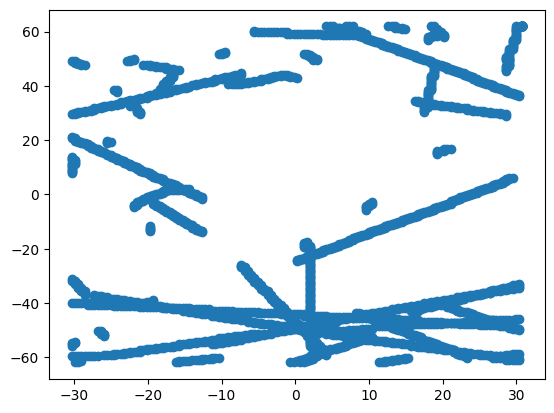

In [5]:
xpitch, ypitch, plane, eid = id2pixel(ref_params, pixels_new)
pixels_coord = get_pixel_coordinates(ref_params, xpitch, ypitch, plane)
plt.scatter(pixels_coord[:, 0], pixels_coord[:, 1])

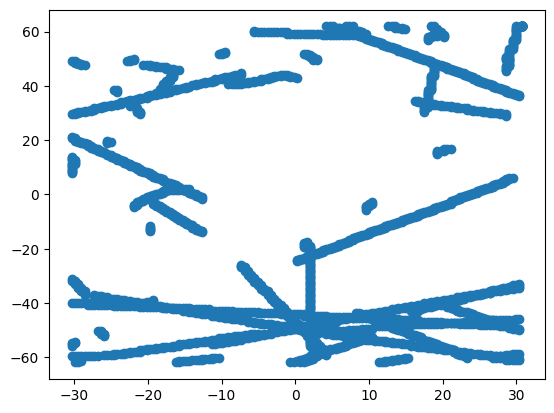

In [6]:
xpitch, ypitch, plane, eid = id2pixel(ref_params, pixels_old)
pixels_coord = get_pixel_coordinates(ref_params, xpitch, ypitch, plane)
plt.scatter(pixels_coord[:, 0], pixels_coord[:, 1])

Pixel id: 79108


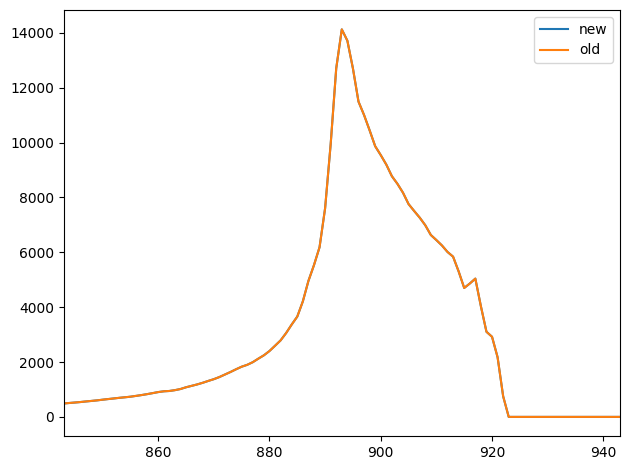

In [6]:
import numpy as np
i = 8
pixid = sorted(overlaps)[i]
print("Pixel id:", pixid)
id_new = np.argwhere(pixels_new == pixid)[0][0]
id_old = np.argwhere(pixels_old == pixid)[0][0]

# plt.plot(np.cumsum(wfs_new[id_new]), label='new')
# plt.plot(np.cumsum(wfs_old[id_old]), label='old')
plt.plot(wfs_new[id_new], label='new')
plt.plot(wfs_old[id_old], label='old')

xmax = np.argmax(wfs_new[id_new])


plt.xlim(xmax - 50, xmax + 50)
plt.legend()
plt.tight_layout()

In [9]:
from tqdm import tqdm
import jax.numpy as jnp
pixids = sorted(overlaps)[1:]
diff_list = []
for i in tqdm(range(len(pixids))):
    pixid = pixids[i]
    id_new = np.argwhere(pixels_new == pixid)[0][0]
    id_old = np.argwhere(pixels_old == pixid)[0][0]

    diff = jnp.sum(wfs_new[id_new] - wfs_old[id_old])
    diff_list.append(diff)
# print(max_diff, pixid)

100%|██████████| 2014/2014 [00:12<00:00, 161.98it/s]


[   0    1    2 ... 2011 2012 2013]


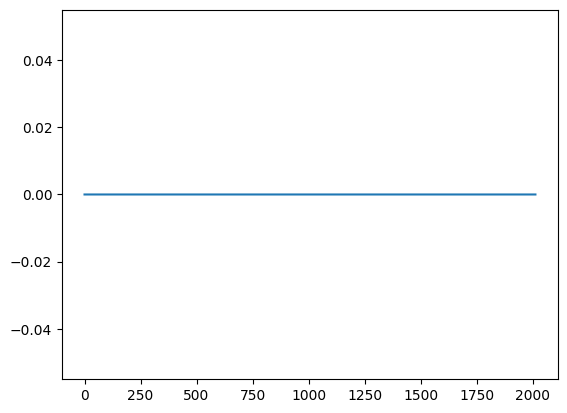

In [11]:
diff_list = np.array(diff_list)
plt.plot(diff_list)
# plt.yscale('log')
print(np.argsort(diff_list))

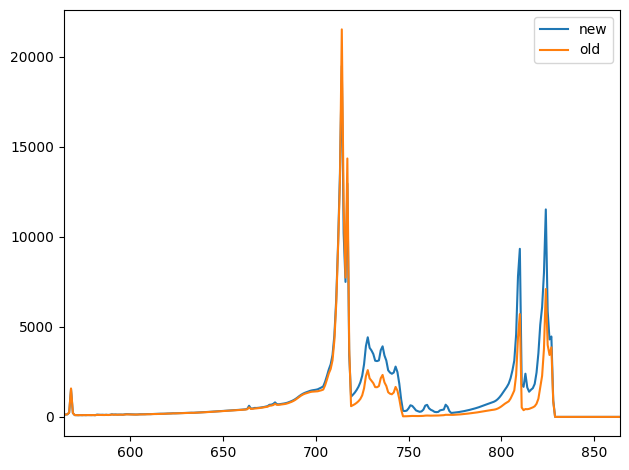

In [9]:
import numpy as np
i = 174
pixid = pixids[i]
id_new = np.argwhere(pixels_new == pixid)[0][0]
id_old = np.argwhere(pixels_old == pixid)[0][0]

# plt.plot(np.cumsum(wfs_new[id_new]), label='new')
# plt.plot(np.cumsum(wfs_old[id_old]), label='old')
plt.plot(wfs_new[id_new], label='new')
plt.plot(wfs_old[id_old], label='old')

xmax = np.argmax(wfs_new[id_new])

# plt.xlim(400, 750)
plt.xlim(xmax - 150, xmax + 150)
plt.legend()
plt.tight_layout()

Pixel id: 79108


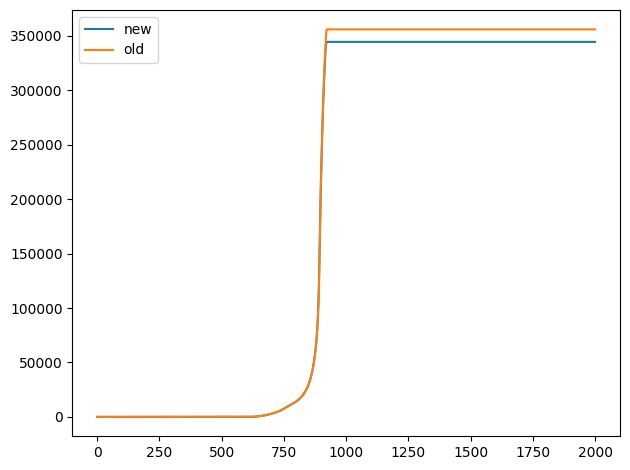

In [19]:
import numpy as np
i = 8
pixid = sorted(overlaps)[i]
print("Pixel id:", pixid)
id_new = np.argwhere(pixels_new == pixid)[0][0]
id_old = np.argwhere(pixels_old == pixid)[0][0]

plt.plot(np.cumsum(wfs_new[id_new]), label='new')
plt.plot(np.cumsum(wfs_old[id_old]), label='old')

xmax = np.argmax(np.cumsum(wfs_new[id_new]))


# plt.xlim(xmax - 100, xmax + 50)
plt.legend()
plt.tight_layout()